First 5 rows with Binary Column:

   Exam_Score  Pass
0   72.666667     1
1   82.333333     1
2   92.666667     1
3   49.333333     0
4   76.333333     1

========== PART A: BERNOULLI DISTRIBUTION ==========

Probability of Success (p): 0.715
Probability of Failure (1 - p): 0.28500000000000003
Mean E(X): 0.715
Variance Var(X): 0.203775

Bernoulli PMF: {0: 0.28500000000000003, 1: 0.715}


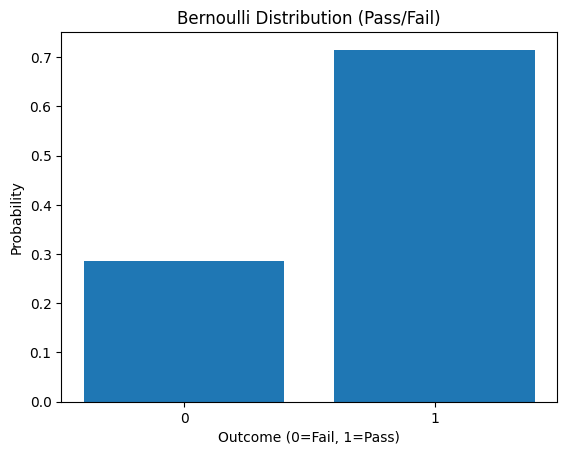

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

df = pd.read_csv("StudentsPerformance.csv")

# Clean dataset
df = df.drop_duplicates()
df = df.dropna()

# Create Exam_Score as average
df["Exam_Score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

# Convert to binary Pass/Fail
df["Pass"] = np.where(df["Exam_Score"] >= 60, 1, 0)

print("First 5 rows with Binary Column:\n")
print(df[["Exam_Score", "Pass"]].head())

# PART A: BERNOULLI DISTRIBUTION
print("\n========== PART A: BERNOULLI DISTRIBUTION ==========\n")

p = df["Pass"].mean()
q = 1 - p

print("Probability of Success (p):", p)
print("Probability of Failure (1 - p):", q)

mean_bernoulli = p
variance_bernoulli = p * (1 - p)

print("Mean E(X):", mean_bernoulli)
print("Variance Var(X):", variance_bernoulli)

bernoulli_pmf = {0: q, 1: p}
print("\nBernoulli PMF:", bernoulli_pmf)

plt.figure()
plt.bar([0, 1], [q, p])
plt.xticks([0, 1])
plt.title("Bernoulli Distribution (Pass/Fail)")
plt.xlabel("Outcome (0=Fail, 1=Pass)")
plt.ylabel("Probability")
plt.show()


========== PART B: BINOMIAL DISTRIBUTION ==========

Binomial PMF for n=5 students (probability of k passes):
P(0 passes) = 0.0019
P(1 passes) = 0.0236
P(2 passes) = 0.1183
P(3 passes) = 0.2969
P(4 passes) = 0.3724
P(5 passes) = 0.1869


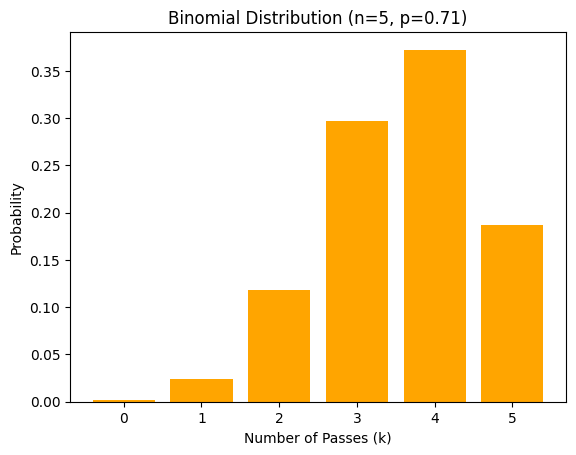

In [8]:
# PART B: BINOMIAL DISTRIBUTION
print("\n========== PART B: BINOMIAL DISTRIBUTION ==========\n")

# Number of trials (students selected in a group)
n = 5  # you can change this number

# Probability of success (Pass)
p = df["Pass"].mean()

# Possible number of successes (0 to n)
k = np.arange(0, n + 1)

# Calculate Binomial PMF
binom_pmf = binom.pmf(k, n, p)

# Display probabilities
print(f"Binomial PMF for n={n} students (probability of k passes):")
for i, prob in zip(k, binom_pmf):
    print(f"P({i} passes) = {prob:.4f}")

# Plot Binomial Distribution
plt.figure()
plt.bar(k, binom_pmf, color='orange')
plt.xlabel("Number of Passes (k)")
plt.ylabel("Probability")
plt.title(f"Binomial Distribution (n={n}, p={p:.2f})")
plt.xticks(k)
plt.show()